# Model 1 — Flat DDM: Posterior Analysis

**Purpose:**
predictive performance analysis, posterior predictive checks, prior sensitivity analysis, posterior distribution analysis

**Outputs:** `models/figs/*.png`

## Imports and load


In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from scipy import stats

RESULTS_DIR = Path("results")
FIGS_DIR = Path("figs")
FIGS_DIR.mkdir(exist_ok=True)

DATA_PATH   = Path("../EDA/data/dataset.csv")
LEGEND_PATH = Path("../EDA/data/player_id_legend.csv")

A_FIXED = 1.5
T_FIXED = 0.05

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
EASY_COLOR = "#4C72B0"
HARD_COLOR = "#DD8452"

fit_path = RESULTS_DIR / "flat_fit.pkl"

with open(fit_path, "rb") as f:
    fit = pickle.load(f)

df = pd.read_csv(DATA_PATH)
draws = fit.draws_pd()
summary = fit.summary()

stan_data = {
    "N":          len(df),
    "choice":     df["choice"].astype(int).tolist(),
    "RT":         df["RT"].tolist(),
    "difficulty": df["difficulty_bin"].astype(int).tolist(),
}

print(f"Loaded fit. Draws shape: {draws.shape}")
print(f"Dataset: {len(df):,} trials")
print(f"\nPosterior summary:")
print(summary.to_string())

/Users/nidhipad/Dropbox/Mac/Downloads/Cognitive-Modeling-Capstone-Project/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded fit. Draws shape: (4000, 22279)
Dataset: 22,263 trials

Posterior summary:
                            Mean      MCSE    StdDev       MAD            5%           50%           95%  ESS_bulk  ESS_tail  ESS_bulk/s     R_hat
lp__               -29862.100000  0.028008  1.217380  0.997049 -29864.500000 -29861.800000 -29860.800000   1953.42   2428.64     3.63001  1.001560
v_easy                  0.303973  0.000264  0.012921  0.012811      0.282203      0.303836      0.325314   2430.93   2733.58     4.51736  1.001090
v_hard                  0.286643  0.000212  0.010634  0.010782      0.269091      0.286733      0.303918   2568.63   3013.12     4.77325  1.000260
beta_logit             -0.192332  0.000214  0.010175  0.010079     -0.209256     -0.192152     -0.176001   2296.67   2444.91     4.26787  1.001510
beta                    0.452066  0.000053  0.002520  0.002497      0.447876      0.452109      0.456113   2296.67   2444.91     4.26786  1.001520
v_diff                  0.017330  0.

## Save figure

In [2]:
def save_fig(filename: str) -> None:
    path = FIGS_DIR / filename
    plt.savefig(path, dpi=150, bbox_inches="tight")
    print(f"Saved: {path}")

## Simulate DDM responses

In [3]:
def simulate_ddm(
    v: float,
    a: float,
    t: float,
    beta: float,
    n_trials: int,
    dt: float = 0.001,
    max_steps: int = 10000,
) -> tuple:
    rts     = np.full(n_trials, np.nan)
    choices = np.full(n_trials, np.nan)

    for i in range(n_trials):
        x     = beta * a
        steps = 0
        while steps < max_steps:
            x     += v * dt + np.sqrt(dt) * np.random.randn()
            steps += 1
            if x >= a:
                rts[i]     = steps * dt + t
                choices[i] = 1
                break
            elif x <= 0:
                rts[i]     = steps * dt + t
                choices[i] = 0
                break

    valid   = ~np.isnan(rts)
    return rts[valid], choices[valid]

## Compute LOO-IC

In [4]:
import arviz as az

idata = az.from_cmdstanpy(fit)
loo   = az.loo(idata)
print(loo)

Computed from 4000 posterior samples and 22263 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -29862.86   105.86
p_loo        1.57        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     22263  100.0%
   (0.70, 1]   (bad)          0    0.0%
   (1, Inf)   (very bad)     0    0.0%



## Posterior predictive check — RT distributions

Saved: figs/ppc_rt_distributions.png


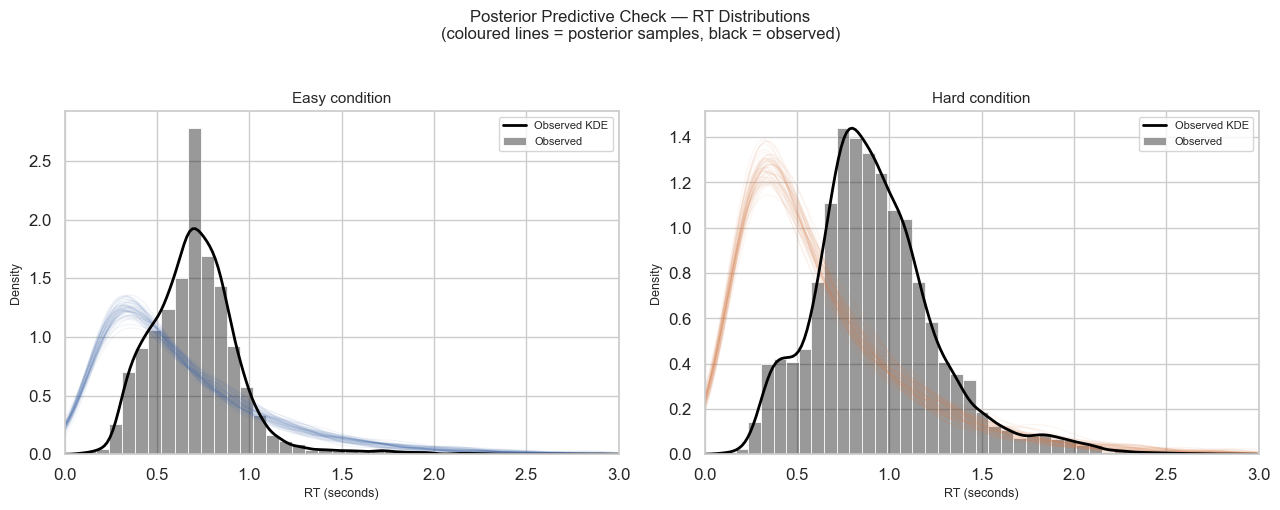

In [5]:
def posterior_predictive_rt(
    draws: pd.DataFrame,
    df: pd.DataFrame,
    n_posterior_samples: int = 50,
    n_sim_trials: int = 500,
) -> None:
    """
    Plots observed RT histogram overlaid with simulated RT distributions
    for easy and hard conditions separately
    """
    sampled   = draws.iloc[
        np.random.choice(len(draws), n_posterior_samples, replace=False)
    ]
    beta_vals = (
        sampled["beta"].values
        if "beta" in draws.columns
        else np.full(n_posterior_samples, 0.5)
    )

    conditions = {
        "Easy condition": (
            df[df["difficulty_bin"] == 0]["RT"].values,
            sampled["v_easy"].values,
            EASY_COLOR,
        ),
        "Hard condition": (
            df[df["difficulty_bin"] == 1]["RT"].values,
            sampled["v_hard"].values,
            HARD_COLOR,
        ),
    }

    fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)

    for ax, (title, (obs, v_vals, color)) in zip(axes, conditions.items()):
        for v, b in zip(v_vals, beta_vals):
            sim_rts, _ = simulate_ddm(
                v=v, a=A_FIXED, t=T_FIXED, beta=b, n_trials=n_sim_trials
            )
            sim_rts = sim_rts[(sim_rts >= 0.1) & (sim_rts <= 3.0)]
            if len(sim_rts) > 10:
                sns.kdeplot(
                    sim_rts, ax=ax, color=color, alpha=0.08, linewidth=0.8
                )

        sns.histplot(
            obs, ax=ax, stat="density", bins=40,
            color="black", alpha=0.4, label="Observed",
        )
        sns.kdeplot(
            obs, ax=ax, color="black", linewidth=2, label="Observed KDE"
        )

        ax.set_title(title, fontsize=11)
        ax.set_xlabel("RT (seconds)", fontsize=9)
        ax.set_ylabel("Density", fontsize=9)
        ax.set_xlim(0, 3)
        ax.legend(fontsize=8)

    fig.suptitle(
        "Posterior Predictive Check — RT Distributions\n"
        "(coloured lines = posterior samples, black = observed)",
        fontsize=12,
        y=1.02,
    )
    plt.tight_layout()
    save_fig("ppc_rt_distributions.png")
    plt.show()


posterior_predictive_rt(draws, df)

## Posterior predictive check — choice rates

Easy — Observed: 0.585, Predicted: 0.568
Hard — Observed: 0.620, Predicted: 0.563
Saved: figs/ppc_choice_rates.png


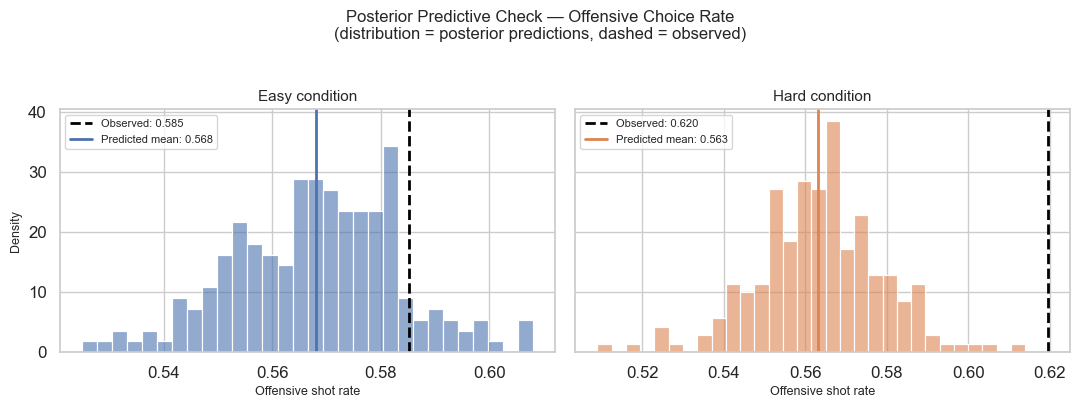

In [6]:
def posterior_predictive_choice(
    draws: pd.DataFrame,
    df: pd.DataFrame,
    n_posterior_samples: int = 200,
    n_sim_trials: int = 1000,
) -> None:
    """
    Compares observed offensive shot rate to distribution of
    model-predicted offensive rates across posterior samples
    """
    sampled   = draws.iloc[
        np.random.choice(len(draws), n_posterior_samples, replace=False)
    ].reset_index(drop=True)
    beta_vals = (
        sampled["beta"].values
        if "beta" in draws.columns
        else np.full(n_posterior_samples, 0.5)
    )

    conditions = {
        "Easy": (
            df[df["difficulty_bin"] == 0]["choice"].mean(),
            sampled["v_easy"].values,
        ),
        "Hard": (
            df[df["difficulty_bin"] == 1]["choice"].mean(),
            sampled["v_hard"].values,
        ),
    }

    fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
    colors = {"Easy": EASY_COLOR, "Hard": HARD_COLOR}

    for ax, (label, (obs, v_vals)) in zip(axes, conditions.items()):
        pred = [
            simulate_ddm(
                v=v, a=A_FIXED, t=T_FIXED, beta=b, n_trials=n_sim_trials
            )[1].mean()
            for v, b in zip(v_vals, beta_vals)
        ]
        sns.histplot(
            pred, ax=ax, color=colors[label], alpha=0.6, bins=30, stat="density"
        )
        ax.axvline(
            obs, color="black", linewidth=2, linestyle="--",
            label=f"Observed: {obs:.3f}",
        )
        ax.axvline(
            np.mean(pred), color=colors[label], linewidth=2,
            label=f"Predicted mean: {np.mean(pred):.3f}",
        )
        ax.set_title(f"{label} condition", fontsize=11)
        ax.set_xlabel("Offensive shot rate", fontsize=9)
        ax.set_ylabel("Density", fontsize=9)
        ax.legend(fontsize=8)
        print(f"{label} — Observed: {obs:.3f}, Predicted: {np.mean(pred):.3f}")

    fig.suptitle(
        "Posterior Predictive Check — Offensive Choice Rate\n"
        "(distribution = posterior predictions, dashed = observed)",
        fontsize=12,
        y=1.02,
    )
    plt.tight_layout()
    save_fig("ppc_choice_rates.png")
    plt.show()


posterior_predictive_choice(draws, df)

## Prior Sensitivity Analysis

Saved: figs/prior_vs_posterior.png


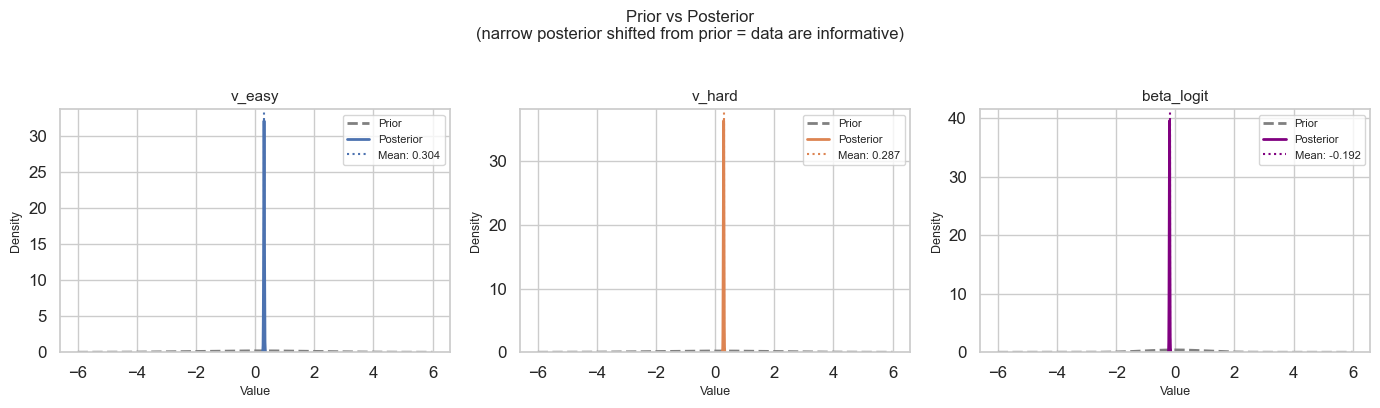

In [7]:
def plot_prior_vs_posterior(draws: pd.DataFrame) -> None:

    x_range = np.linspace(-6, 6, 400)

    params = {
        "v_easy":     {"prior_mu": 0, "prior_sigma": 2, "color": EASY_COLOR},
        "v_hard":     {"prior_mu": 0, "prior_sigma": 2, "color": HARD_COLOR},
        "beta_logit": {"prior_mu": 0, "prior_sigma": 1, "color": "purple"},
    }

    fig, axes = plt.subplots(1, len(params), figsize=(14, 4))

    for ax, (param, cfg) in zip(axes, params.items()):
        if param not in draws.columns:
            continue
        posterior = draws[param].values
        prior_pdf = stats.norm.pdf(
            x_range, cfg["prior_mu"], cfg["prior_sigma"]
        )

        ax.plot(
            x_range, prior_pdf,
            color="gray", linewidth=2, linestyle="--", label="Prior",
        )
        sns.kdeplot(
            posterior, ax=ax,
            color=cfg["color"], linewidth=2, label="Posterior",
        )
        ax.axvline(
            posterior.mean(),
            color=cfg["color"], linestyle=":", linewidth=1.5,
            label=f"Mean: {posterior.mean():.3f}",
        )
        ax.set_title(param, fontsize=11)
        ax.set_xlabel("Value", fontsize=9)
        ax.set_ylabel("Density", fontsize=9)
        ax.legend(fontsize=8)

    fig.suptitle(
        "Prior vs Posterior\n"
        "(narrow posterior shifted from prior = data are informative)",
        fontsize=12,
        y=1.02,
    )
    plt.tight_layout()
    save_fig("prior_vs_posterior.png")
    plt.show()


plot_prior_vs_posterior(draws)

## Joint posterior plot of v_easy vs v_hard

Saved: figs/joint_posterior_v_easy_v_hard.png


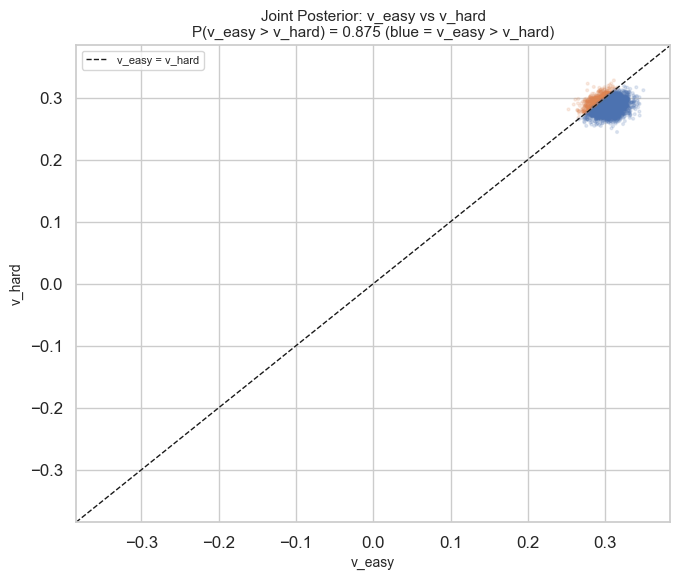

P(v_easy > v_hard) = 0.8748


In [8]:
def plot_joint_posterior(draws: pd.DataFrame) -> None:
    """
    2D joint posterior of v_easy and v_hard.
    Blue = v_easy > v_hard, orange = v_easy <= v_hard.
    """
    v_easy         = draws["v_easy"].values
    v_hard         = draws["v_hard"].values
    p_easy_gt_hard = (v_easy > v_hard).mean()

    fig, ax = plt.subplots(figsize=(7, 6))

    colors = np.where(v_easy > v_hard, EASY_COLOR, HARD_COLOR)
    ax.scatter(
        v_easy, v_hard,
        c=colors, alpha=0.15, s=4, rasterized=True,
    )

    lim = max(abs(v_easy).max(), abs(v_hard).max()) * 1.1
    ax.plot(
        [-lim, lim], [-lim, lim],
        "k--", linewidth=1, label="v_easy = v_hard",
    )

    ax.set_xlabel("v_easy", fontsize=10)
    ax.set_ylabel("v_hard", fontsize=10)
    ax.set_title(
        f"Joint Posterior: v_easy vs v_hard\n"
        f"P(v_easy > v_hard) = {p_easy_gt_hard:.3f} "
        f"(blue = v_easy > v_hard)",
        fontsize=11,
    )
    ax.legend(fontsize=8)
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)

    plt.tight_layout()
    save_fig("joint_posterior_v_easy_v_hard.png")
    plt.show()

    print(f"P(v_easy > v_hard) = {p_easy_gt_hard:.4f}")


plot_joint_posterior(draws)

## Summary of saved figures

In [ ]:
print("Figures saved to models/figs/:")
for fig_file in sorted(FIGS_DIR.glob("*.png")):
    print(f"  {fig_file.name}")